In [1]:
import os
print(sorted(os.listdir('datos')))

['heuristica_lima.csv', 'heuristica_trujillo.csv', 'rutas_peru_norte.csv', 'rutas_peru_sur.csv']


In [2]:
import csv

# Funciones de la plantilla
def leer_aristas(ruta):
    with open(ruta, encoding='utf-8') as f:
        return list(csv.DictReader(f))

def leer_heuristica(ruta):
    with open(ruta, encoding='utf-8') as f:
        return {r['ciudad'].strip(): int(r['h_km']) for r in csv.DictReader(f)}

# PASO 1
filas = leer_aristas('datos/rutas_peru_sur.csv')
H = leer_heuristica('datos/heuristica_lima.csv')

print('Filas leidas:', len(filas))
for f in filas:
    print(repr(f['origen']), '|', repr(f['destino']), '|', repr(f['distancia_km']))

print('Ciudades en la heuristica:', len(H))

Filas leidas: 16
'Cusco' | 'Abancay' | '195'
'Abancay' | 'Andahuaylas' | '138'
'Abancay' | 'Puquio' | '350'
'Andahuaylas' | 'Ayacucho' | '260'
'Ayacucho' | 'Huancavelica' | '245'
'Ayacucho' | 'Pisco' | '320'
'Huancavelica' | 'Huancayo' | '147'
'Huancayo' | 'La Oroya' | '125'
'La Oroya' | 'Lima' | '187'
'Puquio' | 'Nazca' | '155'
'Nasca ' | 'Ica' | '145'
'Ica' | 'Pisco' | '75'
'Pisco' | 'Chincha' | '60'
'Chincha' | 'Lima' | '200'
'Chincha' | 'Lima' | '200'
' Lima' | 'La Oroya' | ''
Ciudades en la heuristica: 13


In [3]:
# PASO 2
ALIAS = {'nazca': 'Nasca'}

def limpiar(filas_brutas):
    aristas = []
    vistas = set()
    for f in filas_brutas:
        # R1: strip (eliminar espacios)
        origen = f['origen'].strip()
        destino = f['destino'].strip()

        # R2: normalizar (corregir Nazca por Nasca)
        if origen.lower() in ALIAS: origen = ALIAS[origen.lower()]
        if destino.lower() in ALIAS: destino = ALIAS[destino.lower()]

        # R3: ignorar si no hay distancia válida
        if not f['distancia_km'] or not f['distancia_km'].isdigit():
            continue

        costo = int(f['distancia_km'])

        # R4: eliminar repetidas (usando frozenset)
        clave = frozenset({origen, destino})
        if clave in vistas:
            continue

        vistas.add(clave)
        aristas.append((origen, destino, costo))
    return aristas

def construir_grafo(aristas):
    G = {}
    for o, d, km in aristas:
        G.setdefault(o, []).append((d, km))
        G.setdefault(d, []).append((o, km))

    # Ordenar alfabéticamente los vecinos como exige la guía
    for ciudad in G:
        G[ciudad].sort()
    return G

aristas = limpiar(filas)
G = construir_grafo(aristas)

print('Aristas limpias:', len(aristas))
print('Ciudades:', len(G))
print('Vecinos de Abancay:', G['Abancay'])
print('Vecinos de Pisco  :', G['Pisco'])

# Comprobación de simetría del grafo no dirigido
for a in G:
    for b, costo in G[a]:
        assert (a, costo) in G[b], f'arista asimetrica: {a}-{b}'
print('Grafo simetrico: OK')

Aristas limpias: 14
Ciudades: 13
Vecinos de Abancay: [('Andahuaylas', 138), ('Cusco', 195), ('Puquio', 350)]
Vecinos de Pisco  : [('Ayacucho', 320), ('Chincha', 60), ('Ica', 75)]
Grafo simetrico: OK


In [4]:
import heapq

# PASO 3
def costos_optimos_a(G, meta):
    """Calcula h*(n) usando Dijkstra hacia atrás desde la meta"""
    dist = {meta: 0}
    pq = [(0, meta)]
    while pq:
        d, n = heapq.heappop(pq)
        if d > dist.get(n, float("inf")): continue
        if n in G:
            for m, costo in G[n]:
                if d + costo < dist.get(m, float("inf")):
                    dist[m] = d + costo
                    heapq.heappush(pq, (d + costo, m))
    return dist

def verificar_heuristica(G, H, meta):
    h_estrella = costos_optimos_a(G, meta)

    # Admisibilidad: h(n) <= h*(n)
    no_adm = [n for n in H if H[n] > h_estrella.get(n, float('inf'))]

    # Consistencia: h(n) <= c(n, m) + h(m)
    inc = []
    for n in G:
        for m, c in G[n]:
            if n in H and m in H:
                if H[n] > c + H[m]:
                    inc.append((n, m))
    return no_adm, inc

no_adm, inc = verificar_heuristica(G, H, 'Lima')
print('Admisible  :', 'SI' if not no_adm else no_adm)
print('Consistente:', 'SI' if not inc else inc)
print()

h_estrella = costos_optimos_a(G, 'Lima')
print(f"{'ciudad':14s}|{'h':>6s}|{'h*':>7s}|{'h/h*':>8s}")
for ciudad in sorted(H, key=lambda x: h_estrella.get(x, 0)):
    razon = H[ciudad] / h_estrella[ciudad] if h_estrella.get(ciudad) else 1.0
    print(f'{ciudad:14s}|{H[ciudad]:6d}|{h_estrella.get(ciudad, 0):7d}|{razon:8.2f}')

Admisible  : SI
Consistente: SI

ciudad        |     h|     h*|    h/h*
Lima          |     0|      0|    1.00
La Oroya      |   110|    187|    0.59
Chincha       |   165|    200|    0.82
Pisco         |   190|    260|    0.73
Huancayo      |   170|    312|    0.54
Ica           |   240|    335|    0.72
Huancavelica  |   210|    459|    0.46
Nasca         |   320|    480|    0.67
Ayacucho      |   265|    580|    0.46
Puquio        |   380|    635|    0.60
Andahuaylas   |   390|    840|    0.46
Abancay       |   425|    978|    0.43
Cusco         |   574|   1173|    0.49


In [5]:
# PASO 4: Instrumentación
class Metricas:
    def __init__(self, nombre):
        self.nombre = nombre
        self.expandidos = 0
        self.generados = 0
        self.frontera_max = 0

    def observar_frontera(self, tamano):
        self.frontera_max = max(self.frontera_max, tamano)

    def expandir(self):
        self.expandidos += 1

    def generar(self):
        self.generados += 1

    def fila(self, costo):
        return (self.nombre, costo, self.expandidos, self.generados, self.frontera_max)

# Función de apoyo para reconstruir caminos y calcular costos
def reconstruir(padre, meta):
    camino, actual = [], meta
    while actual is not None:
        camino.append(actual)
        actual = padre[actual]
    return camino[::-1]

def costo_camino(G, camino):
    if not camino or len(camino) < 2: return 0
    costo_total = 0
    for a, b in zip(camino, camino[1:]):
        # Buscar el costo en la lista de adyacencia de 'a'
        for vecino, costo in G[a]:
            if vecino == b:
                costo_total += costo
                break
    return costo_total

In [6]:
from collections import deque

# PASO 5.1: BFS
def bfs(G, inicio, meta):
    m = Metricas('BFS')
    padre = {inicio: None}
    frontera = deque([inicio])
    explorados = {inicio}
    m.generar() # cuenta el nodo inicial

    while frontera:
        m.observar_frontera(len(frontera))
        n = frontera.popleft()
        m.expandir()

        if n == meta:
            camino = reconstruir(padre, meta)
            return camino, costo_camino(G, camino), m

        for vecino, _ in G[n]:
            if vecino not in explorados:
                explorados.add(vecino)
                padre[vecino] = n
                m.generar()
                frontera.append(vecino)

    return None, None, m

# PASO 5.2: DFS
def dfs(G, inicio, meta):
    m = Metricas('DFS')
    padre = {inicio: None}
    frontera = [inicio]
    explorados = set()
    m.generar()

    while frontera:
        m.observar_frontera(len(frontera))
        n = frontera.pop()

        if n == meta:
            m.expandir()
            camino = reconstruir(padre, meta)
            return camino, costo_camino(G, camino), m

        if n in explorados:
            continue

        explorados.add(n)
        m.expandir()

        # Apilar vecinos en orden alfabético inverso
        vecinos_inversos = reversed(G[n])
        for vecino, _ in vecinos_inversos:
            if vecino not in explorados:
                padre_tentativo = padre.get(vecino)
                if padre_tentativo is None:
                    padre[vecino] = n
                frontera.append(vecino)
                m.generar()

    return None, None, m

# Ejecución de BFS y DFS
for camino, costo, m in [bfs(G, 'Cusco', 'Lima'), dfs(G, 'Cusco', 'Lima')]:
    print(f'{m.nombre}: {costo} km | expandidos={m.expandidos} generados={m.generados} frontera_max={m.frontera_max}')
    print('   ', ' -> '.join(camino))

BFS: 1173 km | expandidos=13 generados=13 frontera_max=3
    Cusco -> Abancay -> Andahuaylas -> Ayacucho -> Pisco -> Chincha -> Lima
DFS: 1297 km | expandidos=8 generados=10 frontera_max=3
    Cusco -> Abancay -> Andahuaylas -> Ayacucho -> Huancavelica -> Huancayo -> La Oroya -> Lima


In [7]:
# PASO 7: Greedy Best-First
def greedy_best_first(G, inicio, meta, h):
    m = Metricas('Greedy')
    padre = {inicio: None}
    frontera = [(h[inicio], 0, inicio)]  # (prioridad, desempate, ciudad)
    en_frontera = {inicio}
    cerrados = set()
    orden = 0
    m.generar()

    while frontera:
        m.observar_frontera(len(frontera))
        _, _, n = heapq.heappop(frontera)
        en_frontera.discard(n)
        m.expandir()

        if n == meta:
            camino = reconstruir(padre, meta)
            return camino, costo_camino(G, camino), m

        cerrados.add(n)

        for vecino, costo in G[n]:
            if vecino in cerrados or vecino in en_frontera:
                continue
            padre[vecino] = n
            orden += 1
            en_frontera.add(vecino)
            m.generar()
            heapq.heappush(frontera, (h[vecino], orden, vecino))

    return None, None, m

camino, costo, m = greedy_best_first(G, 'Cusco', 'Lima', H)
print(f'{m.nombre}: {costo} km | expandidos={m.expandidos} generados={m.generados} frontera_max={m.frontera_max}')
print('   ', ' -> '.join(camino))

Greedy: 1180 km | expandidos=8 generados=10 frontera_max=3
    Cusco -> Abancay -> Puquio -> Nasca -> Ica -> Pisco -> Chincha -> Lima


In [8]:
# PASO 8: El algoritmo A*
def a_estrella(G, inicio, meta, h, w=1.0, traza=False):
    m = Metricas('A*') if w == 1.0 else Metricas(f'A* (w={w})')
    g = {inicio: 0}
    padre = {inicio: None}
    frontera = [(w * h[inicio], 0, inicio)] # (prioridad, orden, ciudad)
    cerrados = set()
    orden = 0
    m.generar()

    while frontera:
        m.observar_frontera(len(frontera))
        f, _, n = heapq.heappop(frontera)

        # Descartar entradas obsoletas (ya están en cerrados)
        if n in cerrados:
            continue

        m.expandir()

        # Prueba de meta al extraer de la frontera
        if n == meta:
            camino = reconstruir(padre, meta)
            return camino, costo_camino(G, camino), m

        cerrados.add(n)

        if traza:
            print(f"  paso {m.expandidos:2d}: expande {n:13s} g={g[n]:5d} h={h.get(n,0):4d} f={int(f):5d}")

        for vecino, costo in G[n]:
            g_tentativo = g[n] + costo

            # Actualizar si encontramos un camino más barato
            if g_tentativo < g.get(vecino, float("inf")):
                g[vecino] = g_tentativo
                padre[vecino] = n
                orden += 1
                cerrados.discard(vecino) # necesario si la heurística fuera inconsistente
                m.generar()
                heapq.heappush(frontera, (g_tentativo + w * h[vecino], orden, vecino))

    return None, None, m

# PASO 6: Costo Uniforme (Dijkstra) como caso especial de A*
def costo_uniforme(G, inicio, meta):
    h_nula = {nodo: 0 for nodo in G}
    camino, costo, m = a_estrella(G, inicio, meta, h_nula)
    m.nombre = 'Costo uniforme'
    return camino, costo, m

# Ejecución de prueba con traza
camino, costo, m = a_estrella(G, 'Cusco', 'Lima', H, traza=True)
print(' -> '.join(camino))
print(f'costo={costo} expandidos={m.expandidos} generados={m.generados} frontera_max={m.frontera_max}')

  paso  1: expande Cusco         g=    0 h= 574 f=  574
  paso  2: expande Abancay       g=  195 h= 425 f=  620
  paso  3: expande Andahuaylas   g=  333 h= 390 f=  723
  paso  4: expande Ayacucho      g=  593 h= 265 f=  858
  paso  5: expande Puquio        g=  545 h= 380 f=  925
  paso  6: expande Nasca         g=  700 h= 320 f= 1020
  paso  7: expande Huancavelica  g=  838 h= 210 f= 1048
  paso  8: expande Ica           g=  845 h= 240 f= 1085
  paso  9: expande Pisco         g=  913 h= 190 f= 1103
  paso 10: expande Chincha       g=  973 h= 165 f= 1138
  paso 11: expande Huancayo      g=  985 h= 170 f= 1155
Cusco -> Abancay -> Andahuaylas -> Ayacucho -> Pisco -> Chincha -> Lima
costo=1173 expandidos=12 generados=13 frontera_max=3


In [9]:
# PASO 9: Consolidación y Tabla
def imprimir_tabla(resultados):
    print(f"{'Algoritmo':<15} | {'Costo (km)':<10} | {'Expandidos':<10} | {'Generados':<10} | {'Frontera máx.':<13}")
    print("-" * 67)
    for r in resultados:
        print(f"{r[0]:<15} | {r[1]:<10} | {r[2]:<10} | {r[3]:<10} | {r[4]:<13}")

resultados = []
for alg in [bfs(G, 'Cusco', 'Lima'),
            dfs(G, 'Cusco', 'Lima'),
            costo_uniforme(G, 'Cusco', 'Lima'),
            greedy_best_first(G, 'Cusco', 'Lima', H),
            a_estrella(G, 'Cusco', 'Lima', H)]:
    camino, costo, m = alg
    resultados.append(m.fila(costo))

imprimir_tabla(resultados)

Algoritmo       | Costo (km) | Expandidos | Generados  | Frontera máx.
-------------------------------------------------------------------
BFS             | 1173       | 13         | 13         | 3            
DFS             | 1297       | 8          | 10         | 3            
Costo uniforme  | 1173       | 13         | 13         | 3            
Greedy          | 1180       | 8          | 10         | 3            
A*              | 1173       | 12         | 13         | 3            


w=1.0  costo= 1173 expandidos= 12 exceso=  0.0 %  cota w*C*=1173
w=1.5  costo= 1173 expandidos= 11 exceso=  0.0 %  cota w*C*=1760
w=2.0  costo= 1173 expandidos=  8 exceso=  0.0 %  cota w*C*=2346
w=3.0  costo= 1173 expandidos=  8 exceso=  0.0 %  cota w*C*=3519
w=5.0  costo= 1173 expandidos=  7 exceso=  0.0 %  cota w*C*=5865


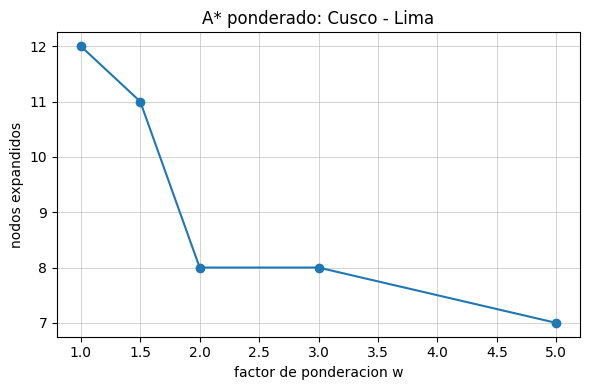

In [10]:
import os
import matplotlib.pyplot as plt

# Crear directorio para la gráfica
os.makedirs('figuras', exist_ok=True)

resultados_w = []
for w in (1.0, 1.5, 2.0, 3.0, 5.0):
    camino, costo, m = a_estrella(G, 'Cusco', 'Lima', H, w=w)
    exceso = 100 * (costo - 1173) / 1173
    resultados_w.append((w, costo, m.expandidos, exceso))
    print(f'w={w:<4} costo={costo:5d} expandidos={m.expandidos:3d} exceso={exceso:5.1f} %  cota w*C*={w*1173:.0f}')

ws = [r[0] for r in resultados_w]
expandidos = [r[2] for r in resultados_w]

# Generar y guardar la gráfica
plt.figure(figsize=(6, 4))
plt.plot(ws, expandidos, marker='o')
plt.xlabel('factor de ponderacion w')
plt.ylabel('nodos expandidos')
plt.title('A* ponderado: Cusco - Lima')
plt.grid(True, linewidth=0.4)
plt.tight_layout()
plt.savefig('figuras/ponderado.png', dpi=150)
plt.show()

In [11]:
# PASO 11: Romper la admisibilidad
H_mala = dict(H)
H_mala['Ayacucho'] = 700  # Modificamos un único valor para que sobreestime

no_adm, inc = verificar_heuristica(G, H_mala, 'Lima')
print('No admisibles:', no_adm)
print('Inconsistentes:', inc)

camino, costo, m = a_estrella(G, 'Cusco', 'Lima', H_mala)
print(' -> '.join(camino))
print(f'costo={costo} expandidos={m.expandidos}')

No admisibles: ['Ayacucho']
Inconsistentes: [('Ayacucho', 'Andahuaylas'), ('Ayacucho', 'Huancavelica'), ('Ayacucho', 'Pisco')]
Cusco -> Abancay -> Puquio -> Nasca -> Ica -> Pisco -> Chincha -> Lima
costo=1180 expandidos=9


In [12]:
# T1. Grafo ampliado
filas_norte = leer_aristas('datos/rutas_peru_norte.csv')
aristas_norte = limpiar(filas_norte)
G2 = construir_grafo(aristas + aristas_norte) # Unimos sur y norte
print('Aristas:', len(aristas) + len(aristas_norte), '| Ciudades:', len(G2))

# T2. Heuristica hacia la nueva meta
HT = leer_heuristica('datos/heuristica_trujillo.csv')
no_adm, inc = verificar_heuristica(G2, HT, 'Trujillo')
print('Admisible  :', 'SI' if not no_adm else no_adm)
print('Consistente:', 'SI' if not inc else inc)
print()

# T3. Comparacion de los cinco algoritmos (Cusco -> Trujillo)
INICIO, META = 'Cusco', 'Trujillo'
resultados_t3 = []
for alg in [bfs(G2, INICIO, META),
            dfs(G2, INICIO, META),
            costo_uniforme(G2, INICIO, META),
            greedy_best_first(G2, INICIO, META, HT),
            a_estrella(G2, INICIO, META, HT)]:
    camino, costo, m = alg
    resultados_t3.append(m.fila(costo))

print("TABLA COMPARATIVA: CUSCO -> TRUJILLO")
imprimir_tabla(resultados_t3)
print()

# T4. A* Ponderado
print("A* PONDERADO: CUSCO -> TRUJILLO")
print(f"{'w':<4} | {'Costo (km)':<10} | {'Expandidos':<10} | {'Exceso sobre C*':<15}")
print("-" * 50)
for w in (1.0, 1.5, 2.0, 3.0):
    camino, costo, m = a_estrella(G2, INICIO, META, HT, w=w)
    exceso = 100 * (costo - 1738) / 1738
    print(f"{w:<4.1f} | {costo:<10} | {m.expandidos:<10} | {exceso:>5.1f}%")

Aristas: 20 | Ciudades: 18
Admisible  : SI
Consistente: SI

TABLA COMPARATIVA: CUSCO -> TRUJILLO
Algoritmo       | Costo (km) | Expandidos | Generados  | Frontera máx.
-------------------------------------------------------------------
BFS             | 1738       | 18         | 18         | 3            
DFS             | 1862       | 12         | 17         | 6            
Costo uniforme  | 1738       | 18         | 18         | 3            
Greedy          | 1862       | 12         | 16         | 5            
A*              | 1738       | 17         | 19         | 3            

A* PONDERADO: CUSCO -> TRUJILLO
w    | Costo (km) | Expandidos | Exceso sobre C*
--------------------------------------------------
1.0  | 1738       | 17         |   0.0%
1.5  | 1738       | 15         |   0.0%
2.0  | 1862       | 12         |   7.1%
3.0  | 1862       | 12         |   7.1%
